# Gait Analysis Notebook

> Alex Mui
> 
> Mui-Group @ ASDRP
>
> Date: Sat Feb 28 16:30:39 PST 2026

## 1. Import Required Libraries

First, let's import all the necessary libraries and modules for our gait analysis.

In [1]:
# Standard library imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add project root to path (works when run from notebooks/ or project root)
project_root = Path.cwd() if (Path.cwd() / "asdrp").exists() else Path.cwd().parent
sys.path.insert(0, str(project_root))

# Create output directory for figures and exports (avoids FileNotFoundError on savefig)
output_dir = project_root / "data" / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from IPython.display import Video, HTML, display, Image as IPImage
from tqdm.notebook import tqdm

# Project imports - Video processing
from asdrp.video import VideoFileReader, FrameData

# Project imports - Pose estimation
from asdrp.pose import (
    MediaPipePoseEstimator,
    PoseTracker,
    LandmarkProcessor,
    PoseLandmarkIndex,
    PoseLandmarks
)

# Project imports - Analysis
from asdrp.analysis import (
    GaitAnalyzer,
    StrideAnalyzer,
    CadenceAnalyzer,
    SymmetryAnalyzer,
    GaitMetrics,
    GaitEvent,
    Foot
)

# Project imports - Visualization
from asdrp.visualization.overlay import PoseOverlay, LandmarkPoint
from asdrp.visualization.plots import MetricsPlotter

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ All libraries imported successfully!")
print(f"Project root: {project_root}")

✓ All libraries imported successfully!
Project root: /Users/pmui/SynologyDrive/research/2026/research2026/03-pose-estimation


## 2. Load Video Data

Let's load the example running video and inspect its properties.

In [2]:
# Define video path
video_path = project_root / "data" / "runner_example0.mp4"

# Check if video exists
if not video_path.exists():
    raise FileNotFoundError(f"Video not found at: {video_path}")

# Load video and get properties
with VideoFileReader(video_path) as reader:
    fps = reader.get_fps()
    frame_count = reader.get_frame_count()
    width, height = reader.get_resolution()
    duration = reader.get_duration()
    
    print("Video Properties:")
    print("=" * 50)
    print(f"Path: {video_path}")
    print(f"Resolution: {width} x {height}")
    print(f"FPS: {fps:.2f}")
    print(f"Total Frames: {frame_count}")
    print(f"Duration: {duration:.2f} seconds")
    print("=" * 50)

# Display the video
print("\nVideo Preview:")
display(Video(str(video_path), width=600))

Video Properties:
Path: /Users/pmui/SynologyDrive/research/2026/research2026/03-pose-estimation/data/runner_example0.mp4
Resolution: 720 x 1280
FPS: 30.00
Total Frames: 361
Duration: 12.03 seconds

Video Preview:


## 3. Setup MediaPipe Pose Landmarker

Initialize the MediaPipe Pose Landmarker model for pose detection.

In [3]:
# Define model path
model_path = project_root / "data" / "models" / "pose_landmarker.task"

# Check if model exists
if not model_path.exists():
    print("⚠️  Model not found!")
    print(f"Please download the MediaPipe Pose Landmarker model from:")
    print("https://developers.google.com/mediapipe/solutions/vision/pose_landmarker")
    print(f"And place it at: {model_path}")
else:
    print(f"✓ Model found at: {model_path}")

# Initialize pose estimator
try:
    estimator = MediaPipePoseEstimator(
        model_path=str(model_path),
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    )
    print("✓ MediaPipe Pose Landmarker initialized successfully!")
    
    # Initialize tracker for temporal smoothing
    tracker = PoseTracker(window_size=5, sigma=1.0)
    print("✓ Pose tracker initialized (5-frame smoothing window)")
    
except Exception as e:
    print(f"✗ Error initializing estimator: {e}")

✓ Model found at: /Users/pmui/SynologyDrive/research/2026/research2026/03-pose-estimation/data/models/pose_landmarker.task
✓ MediaPipe Pose Landmarker initialized successfully!
✓ Pose tracker initialized (5-frame smoothing window)


I0000 00:00:1772327310.811320 11257511 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Max
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1772327310.864802 11257516 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1772327310.989674 11257513 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 4. Process Video Frame by Frame

Extract pose landmarks from each frame of the video. This may take a few minutes depending on video length.

In [4]:
# Storage for processed data
all_landmarks = []
all_frames = []
landmarks_sequence = []  # For gait analysis

# Process video
print("Processing video frames...")
print("This may take a few minutes...\n")

with VideoFileReader(video_path) as reader:
    frame_count = reader.get_frame_count()
    
    # Process frames with progress bar
    with tqdm(total=frame_count, desc="Processing frames") as pbar:
        frame_idx = 0
        while True:
            # Read frame
            frame_data = reader.read_frame()
            if frame_data is None:
                break
            
            # Estimate pose
            landmarks = estimator.estimate(
                frame_data.image,
                timestamp=frame_data.timestamp,
                frame_number=frame_data.frame_number
            )
            
            # Store results
            if landmarks:
                # Add to tracker for smoothing
                tracker.add_detection(landmarks)
                
                # Get smoothed landmarks
                smoothed = tracker.get_smoothed_landmarks(mode="gaussian")
                
                if smoothed:
                    all_landmarks.append(smoothed)
                    
                    # Convert to dictionary format for gait analysis
                    landmark_dict = {}
                    landmark_names = [
                        'left_hip', 'right_hip',
                        'left_knee', 'right_knee',
                        'left_ankle', 'right_ankle',
                        'left_heel', 'right_heel',
                        'left_foot_index', 'right_foot_index',
                        'left_shoulder', 'right_shoulder'
                    ]
                    
                    landmark_indices = {
                        'left_hip': PoseLandmarkIndex.LEFT_HIP,
                        'right_hip': PoseLandmarkIndex.RIGHT_HIP,
                        'left_knee': PoseLandmarkIndex.LEFT_KNEE,
                        'right_knee': PoseLandmarkIndex.RIGHT_KNEE,
                        'left_ankle': PoseLandmarkIndex.LEFT_ANKLE,
                        'right_ankle': PoseLandmarkIndex.RIGHT_ANKLE,
                        'left_heel': PoseLandmarkIndex.LEFT_HEEL,
                        'right_heel': PoseLandmarkIndex.RIGHT_HEEL,
                        'left_foot_index': PoseLandmarkIndex.LEFT_FOOT_INDEX,
                        'right_foot_index': PoseLandmarkIndex.RIGHT_FOOT_INDEX,
                        'left_shoulder': PoseLandmarkIndex.LEFT_SHOULDER,
                        'right_shoulder': PoseLandmarkIndex.RIGHT_SHOULDER,
                    }
                    
                    for name, idx in landmark_indices.items():
                        lm = smoothed.landmarks[idx.value]
                        vis = smoothed.visibility[idx.value]
                        landmark_dict[name] = {
                            'x': float(lm[0]),
                            'y': float(lm[1]),
                            'z': float(lm[2]),
                            'visibility': float(vis)
                        }
                    
                    landmarks_sequence.append(landmark_dict)
            
            # Store frame for visualization (sample every 10 frames to save memory)
            if frame_idx % 10 == 0:
                all_frames.append(frame_data.image.copy())
            
            frame_idx += 1
            pbar.update(1)

print(f"\n✓ Processing complete!")
print(f"Detected poses in {len(all_landmarks)} / {frame_count} frames")
print(f"Detection rate: {len(all_landmarks)/frame_count*100:.1f}%")

Processing video frames...
This may take a few minutes...



Processing frames:   0%|          | 0/361 [00:00<?, ?it/s]

W0000 00:00:1772327313.486050 11257514 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.



✓ Processing complete!
Detected poses in 361 / 361 frames
Detection rate: 100.0%


## 5. Visualize Pose Keypoints and Skeleton

Let's visualize the detected pose landmarks and skeleton connections on sample frames.

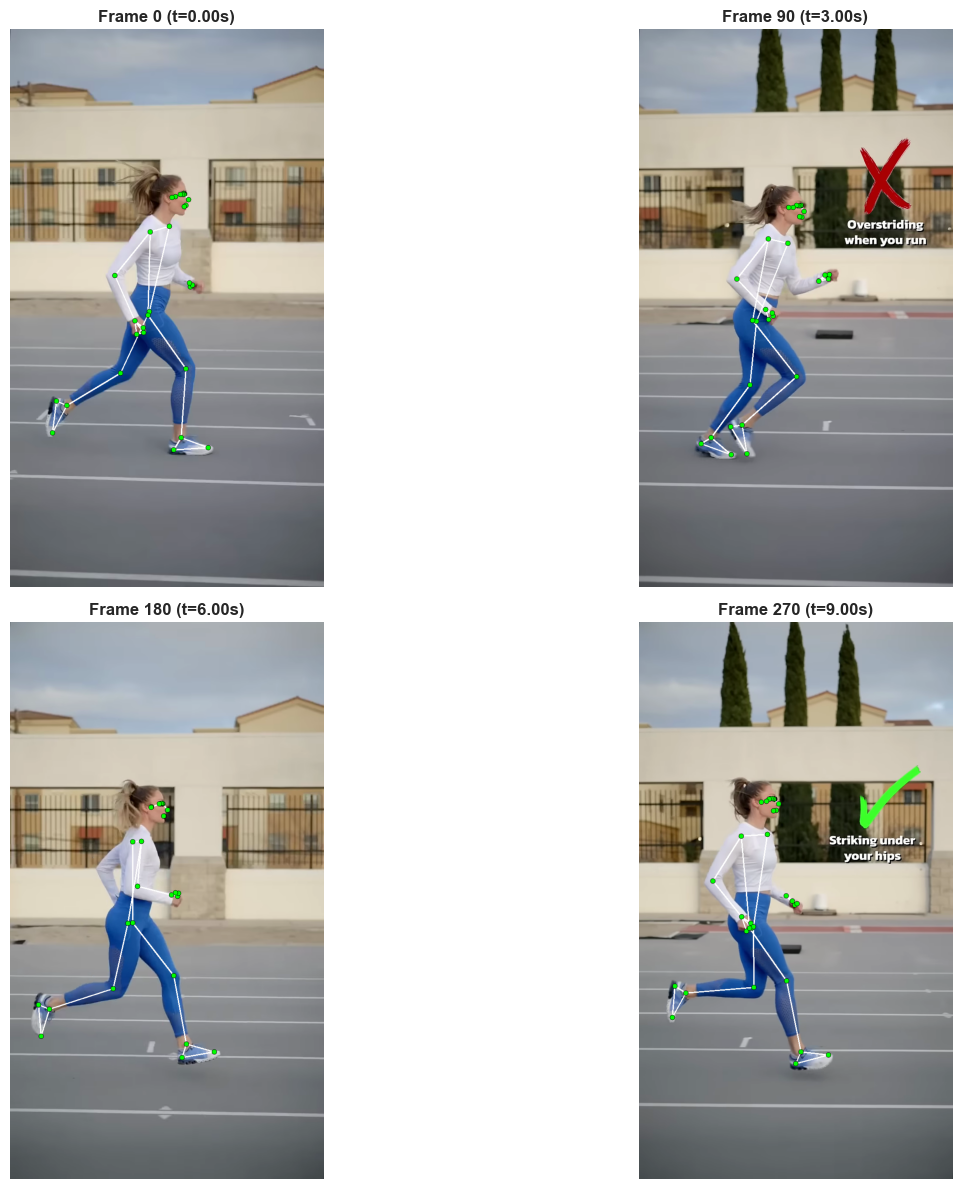

✓ Pose visualization complete!


In [5]:
# Initialize pose overlay visualizer
pose_overlay = PoseOverlay(
    landmark_color=(0, 255, 0),      # Green
    connection_color=(255, 255, 255), # White
    landmark_radius=5,
    connection_thickness=2,
    visibility_threshold=0.5
)

# Select sample frames to visualize
sample_indices = [0, len(all_landmarks)//4, len(all_landmarks)//2, 3*len(all_landmarks)//4]
sample_indices = [idx for idx in sample_indices if idx < len(all_landmarks)]

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, landmark_idx in enumerate(sample_indices[:4]):
    # Get landmarks
    landmarks_data = all_landmarks[landmark_idx]
    
    # Convert to LandmarkPoint objects
    landmark_points = []
    for i in range(33):  # MediaPipe has 33 landmarks
        lm = landmarks_data.landmarks[i]
        vis = landmarks_data.visibility[i]
        landmark_points.append(LandmarkPoint(
            x=float(lm[0]),
            y=float(lm[1]),
            z=float(lm[2]),
            visibility=float(vis)
        ))
    
    # Get corresponding frame (approximate)
    frame_display_idx = min((landmark_idx // 10), len(all_frames) - 1)
    frame = all_frames[frame_display_idx].copy()
    
    # Draw pose
    annotated_frame = pose_overlay.draw_pose(
        frame,
        landmark_points,
        draw_landmarks=True,
        draw_connections=True
    )
    
    # Convert BGR to RGB for matplotlib
    annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
    
    # Display
    axes[idx].imshow(annotated_frame_rgb)
    axes[idx].set_title(f"Frame {landmarks_data.frame_number} (t={landmarks_data.timestamp:.2f}s)", 
                        fontsize=12, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(output_dir / "pose_visualization.png", dpi=150, bbox_inches='tight')
plt.show()

print("✓ Pose visualization complete!")

## 6. Perform Gait Analysis

Now let's analyze the gait metrics including cadence, stride length, and symmetry.

In [6]:
# Initialize gait analyzer
print("Performing gait analysis...")
gait_analyzer = GaitAnalyzer(fps=fps)

# Add metric calculators
gait_analyzer.add_calculator(StrideAnalyzer(fps=fps))
gait_analyzer.add_calculator(CadenceAnalyzer(fps=fps))
gait_analyzer.add_calculator(SymmetryAnalyzer(fps=fps))

# Perform analysis
metrics = gait_analyzer.analyze(landmarks_sequence)

print("\n" + "="*60)
print("GAIT ANALYSIS RESULTS")
print("="*60)
print(f"\nTemporal Metrics:")
print(f"  Cadence:              {metrics.cadence:.1f} steps/min")
print(f"  Stride Time:          {metrics.stride_time:.3f} s")
print(f"  Stance Phase:         {metrics.stance_phase_duration:.3f} s")
print(f"  Swing Phase:          {metrics.swing_phase_duration:.3f} s")

print(f"\nSpatial Metrics:")
print(f"  Stride Length:        {metrics.stride_length:.3f} m")

print(f"\nAngular Metrics:")
print(f"  Max Knee Flexion:     {metrics.knee_flexion_max:.1f}°")
print(f"  Max Hip Extension:    {metrics.hip_extension_max:.1f}°")

print(f"\nSymmetry:")
print(f"  Symmetry Index:       {metrics.symmetry_index:.3f} (0-1, 1=perfect)")

print(f"\nSummary:")
print(f"  Analysis Duration:    {metrics.analysis_duration:.2f} s")
print(f"  Total Strides:        {metrics.total_strides}")
print(f"  Total Events:         {len(metrics.events)}")

print(f"\nLeft Side:")
for key, value in metrics.left_metrics.items():
    print(f"  {key}: {value}")

print(f"\nRight Side:")
for key, value in metrics.right_metrics.items():
    print(f"  {key}: {value}")

print("\n" + "="*60)

# Store metrics for later use
metrics_dict = metrics.to_dict()

Performing gait analysis...

GAIT ANALYSIS RESULTS

Temporal Metrics:
  Cadence:              74.8 steps/min
  Stride Time:          0.954 s
  Stance Phase:         0.363 s
  Swing Phase:          0.522 s

Spatial Metrics:
  Stride Length:        0.079 m

Angular Metrics:
  Max Knee Flexion:     0.0°
  Max Hip Extension:    0.0°

Symmetry:
  Symmetry Index:       0.721 (0-1, 1=perfect)

Summary:
  Analysis Duration:    12.03 s
  Total Strides:        13
  Total Events:         27

Left Side:
  stride_count: 5
  avg_stride_time: 1.0066387811634347
  std_stride_time: 0.5100621174877665

Right Side:
  stride_count: 3
  avg_stride_time: 0.8666426592797783
  std_stride_time: 0.19051059143524415



## 7. Visualize Joint Angles Over Time

Extract and visualize key joint angles throughout the running motion.

In [7]:
# Extract joint angles over time
angles_data = {
    'time': [],
    'left_knee': [],
    'right_knee': [],
    'left_hip': [],
    'right_hip': [],
    'left_ankle': [],
    'right_ankle': []
}

for idx, landmarks in enumerate(all_landmarks):
    time = landmarks.timestamp / 1000.0  # Convert to seconds
    angles_data['time'].append(time)
    
    # Calculate left knee angle
    try:
        left_knee_angle = LandmarkProcessor.get_joint_angle(
            landmarks,
            PoseLandmarkIndex.LEFT_HIP,
            PoseLandmarkIndex.LEFT_KNEE,
            PoseLandmarkIndex.LEFT_ANKLE,
            use_world_coordinates=True
        )
        angles_data['left_knee'].append(left_knee_angle)
    except:
        angles_data['left_knee'].append(np.nan)
    
    # Calculate right knee angle
    try:
        right_knee_angle = LandmarkProcessor.get_joint_angle(
            landmarks,
            PoseLandmarkIndex.RIGHT_HIP,
            PoseLandmarkIndex.RIGHT_KNEE,
            PoseLandmarkIndex.RIGHT_ANKLE,
            use_world_coordinates=True
        )
        angles_data['right_knee'].append(right_knee_angle)
    except:
        angles_data['right_knee'].append(np.nan)
    
    # Calculate left hip angle (using shoulder-hip-knee)
    try:
        left_hip_angle = LandmarkProcessor.get_joint_angle(
            landmarks,
            PoseLandmarkIndex.LEFT_SHOULDER,
            PoseLandmarkIndex.LEFT_HIP,
            PoseLandmarkIndex.LEFT_KNEE,
            use_world_coordinates=True
        )
        angles_data['left_hip'].append(left_hip_angle)
    except:
        angles_data['left_hip'].append(np.nan)
    
    # Calculate right hip angle
    try:
        right_hip_angle = LandmarkProcessor.get_joint_angle(
            landmarks,
            PoseLandmarkIndex.RIGHT_SHOULDER,
            PoseLandmarkIndex.RIGHT_HIP,
            PoseLandmarkIndex.RIGHT_KNEE,
            use_world_coordinates=True
        )
        angles_data['right_hip'].append(right_hip_angle)
    except:
        angles_data['right_hip'].append(np.nan)
    
    # Calculate left ankle angle (using knee-ankle-foot)
    try:
        left_ankle_angle = LandmarkProcessor.get_joint_angle(
            landmarks,
            PoseLandmarkIndex.LEFT_KNEE,
            PoseLandmarkIndex.LEFT_ANKLE,
            PoseLandmarkIndex.LEFT_FOOT_INDEX,
            use_world_coordinates=True
        )
        angles_data['left_ankle'].append(left_ankle_angle)
    except:
        angles_data['left_ankle'].append(np.nan)
    
    # Calculate right ankle angle
    try:
        right_ankle_angle = LandmarkProcessor.get_joint_angle(
            landmarks,
            PoseLandmarkIndex.RIGHT_KNEE,
            PoseLandmarkIndex.RIGHT_ANKLE,
            PoseLandmarkIndex.RIGHT_FOOT_INDEX,
            use_world_coordinates=True
        )
        angles_data['right_ankle'].append(right_ankle_angle)
    except:
        angles_data['right_ankle'].append(np.nan)

# Create DataFrame
angles_df = pd.DataFrame(angles_data)

print(f"✓ Extracted joint angles for {len(angles_df)} frames")
print(f"\nAngle Statistics:")
print(angles_df.describe())

✓ Extracted joint angles for 361 frames

Angle Statistics:
             time   left_knee  right_knee    left_hip   right_hip  left_ankle  \
count  361.000000  361.000000  361.000000  361.000000  361.000000  361.000000   
mean     0.006000  135.208682  124.574932  152.490608  146.068101  133.868528   
std      0.003478   32.325274   30.377823   18.009950   19.214628   14.873649   
min      0.000000   47.253403   54.439411  115.366211  103.065323  105.776428   
25%      0.003000  112.944702  101.570412  137.249420  130.847794  122.430870   
50%      0.006000  150.351151  131.984375  158.222290  144.007111  130.533081   
75%      0.009000  159.550171  148.776962  167.921051  163.779190  147.408432   
max      0.012000  170.372253  171.220291  177.498367  178.917007  163.175537   

       right_ankle  
count   361.000000  
mean    103.914798  
std      23.195931  
min      64.964333  
25%      88.522850  
50%      97.149536  
75%     116.594711  
max     161.400040  


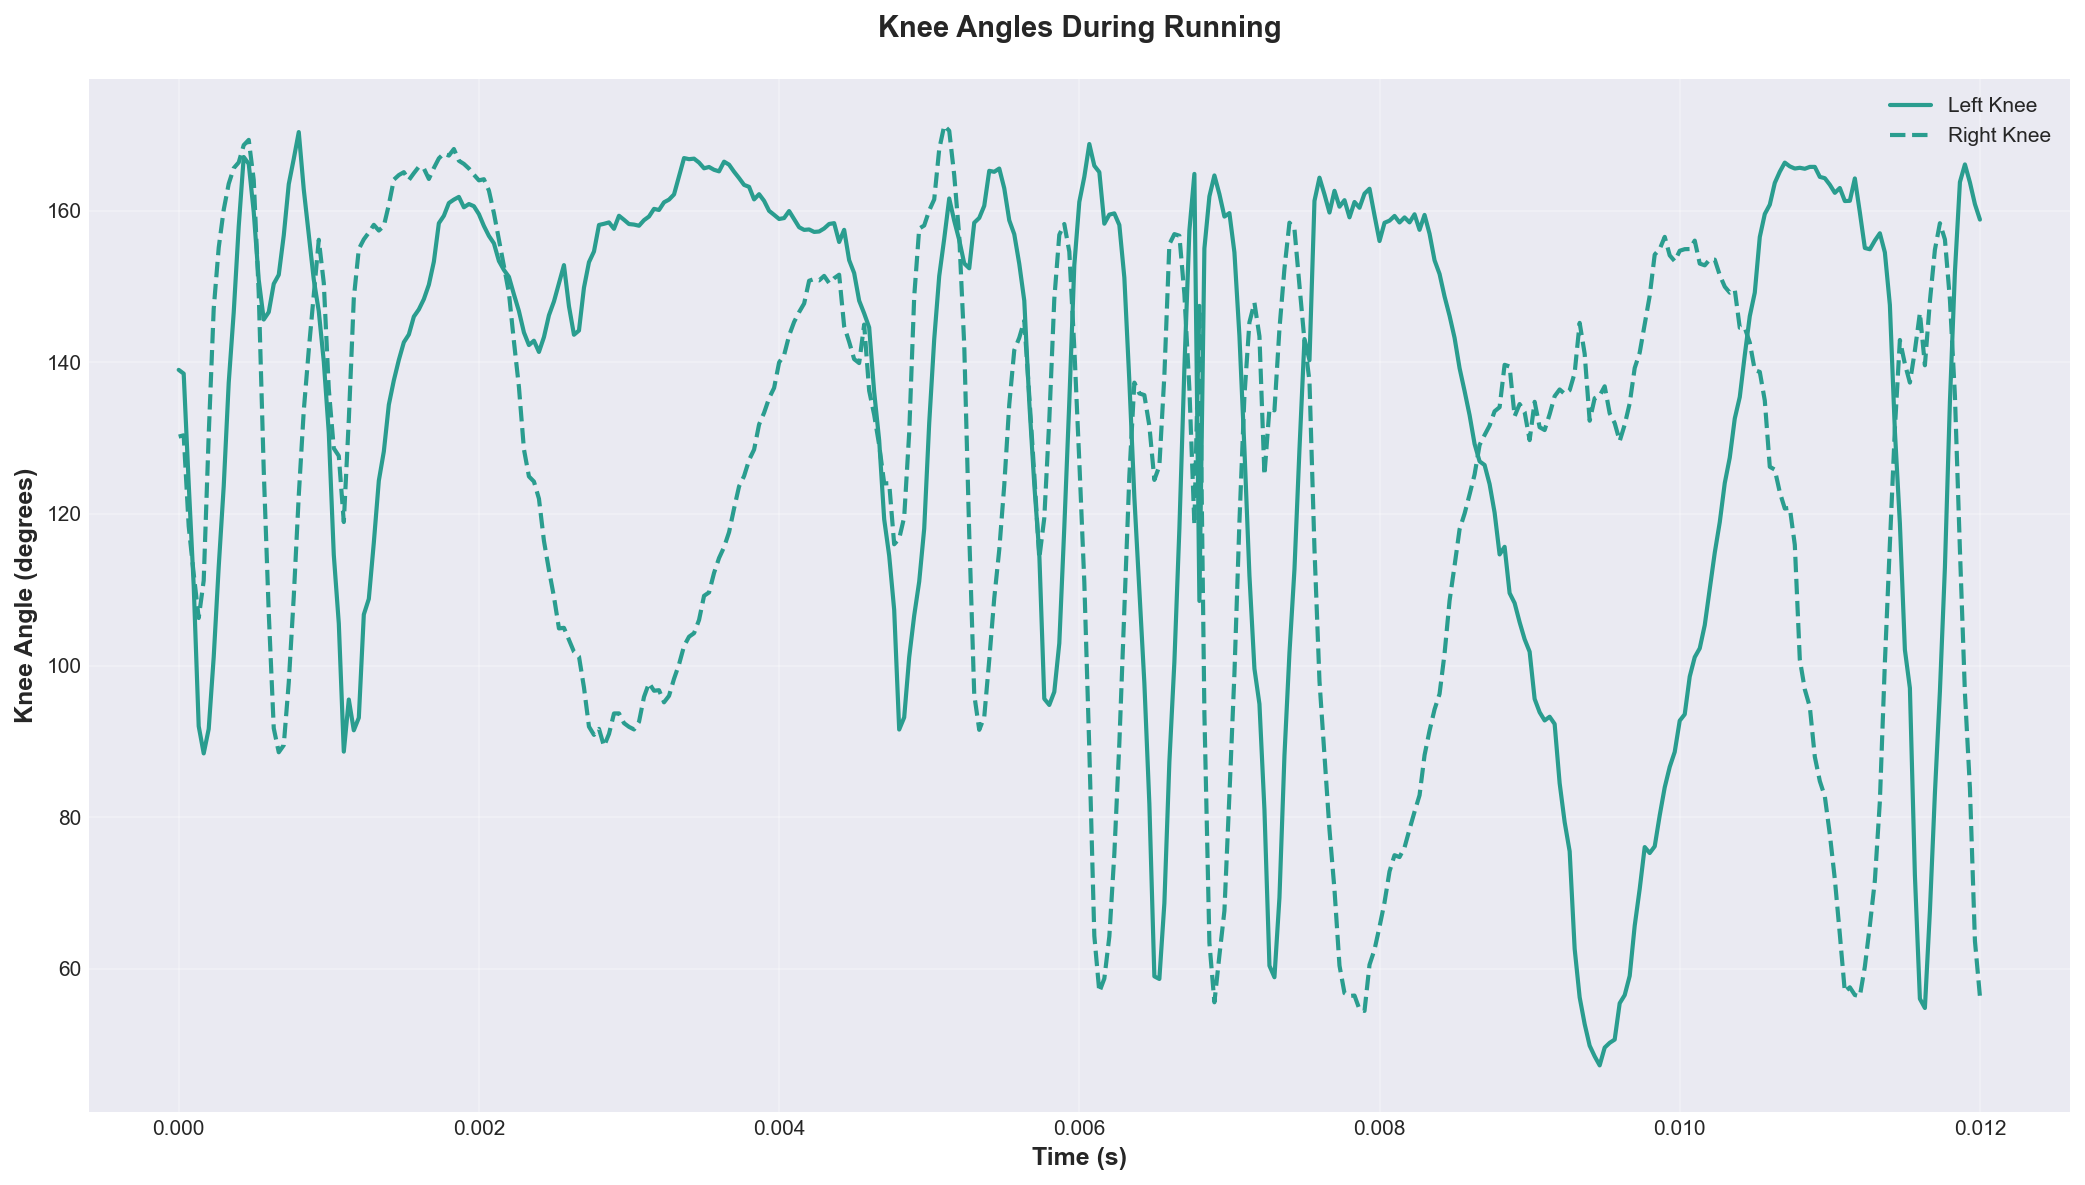

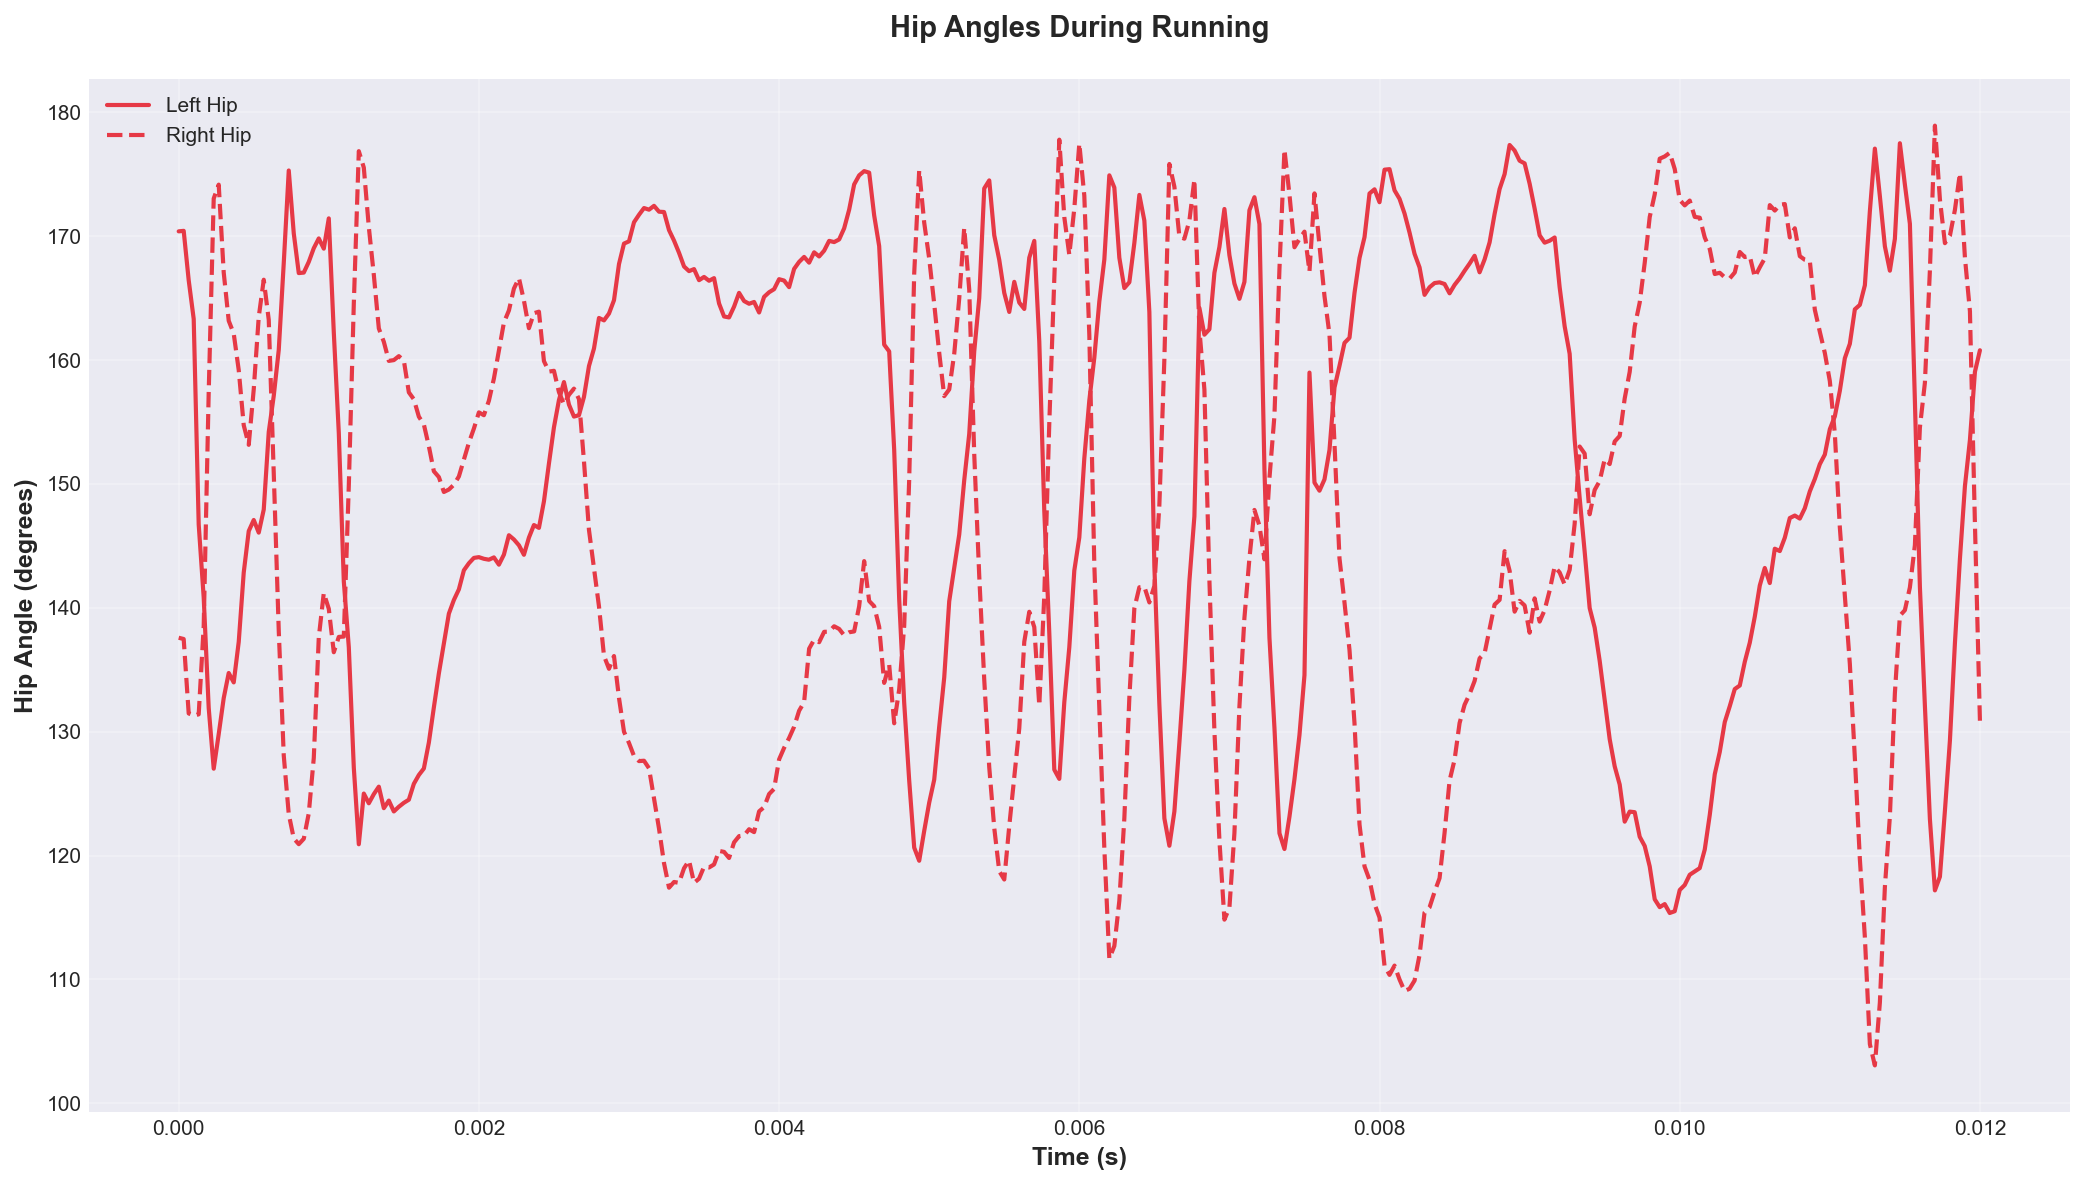

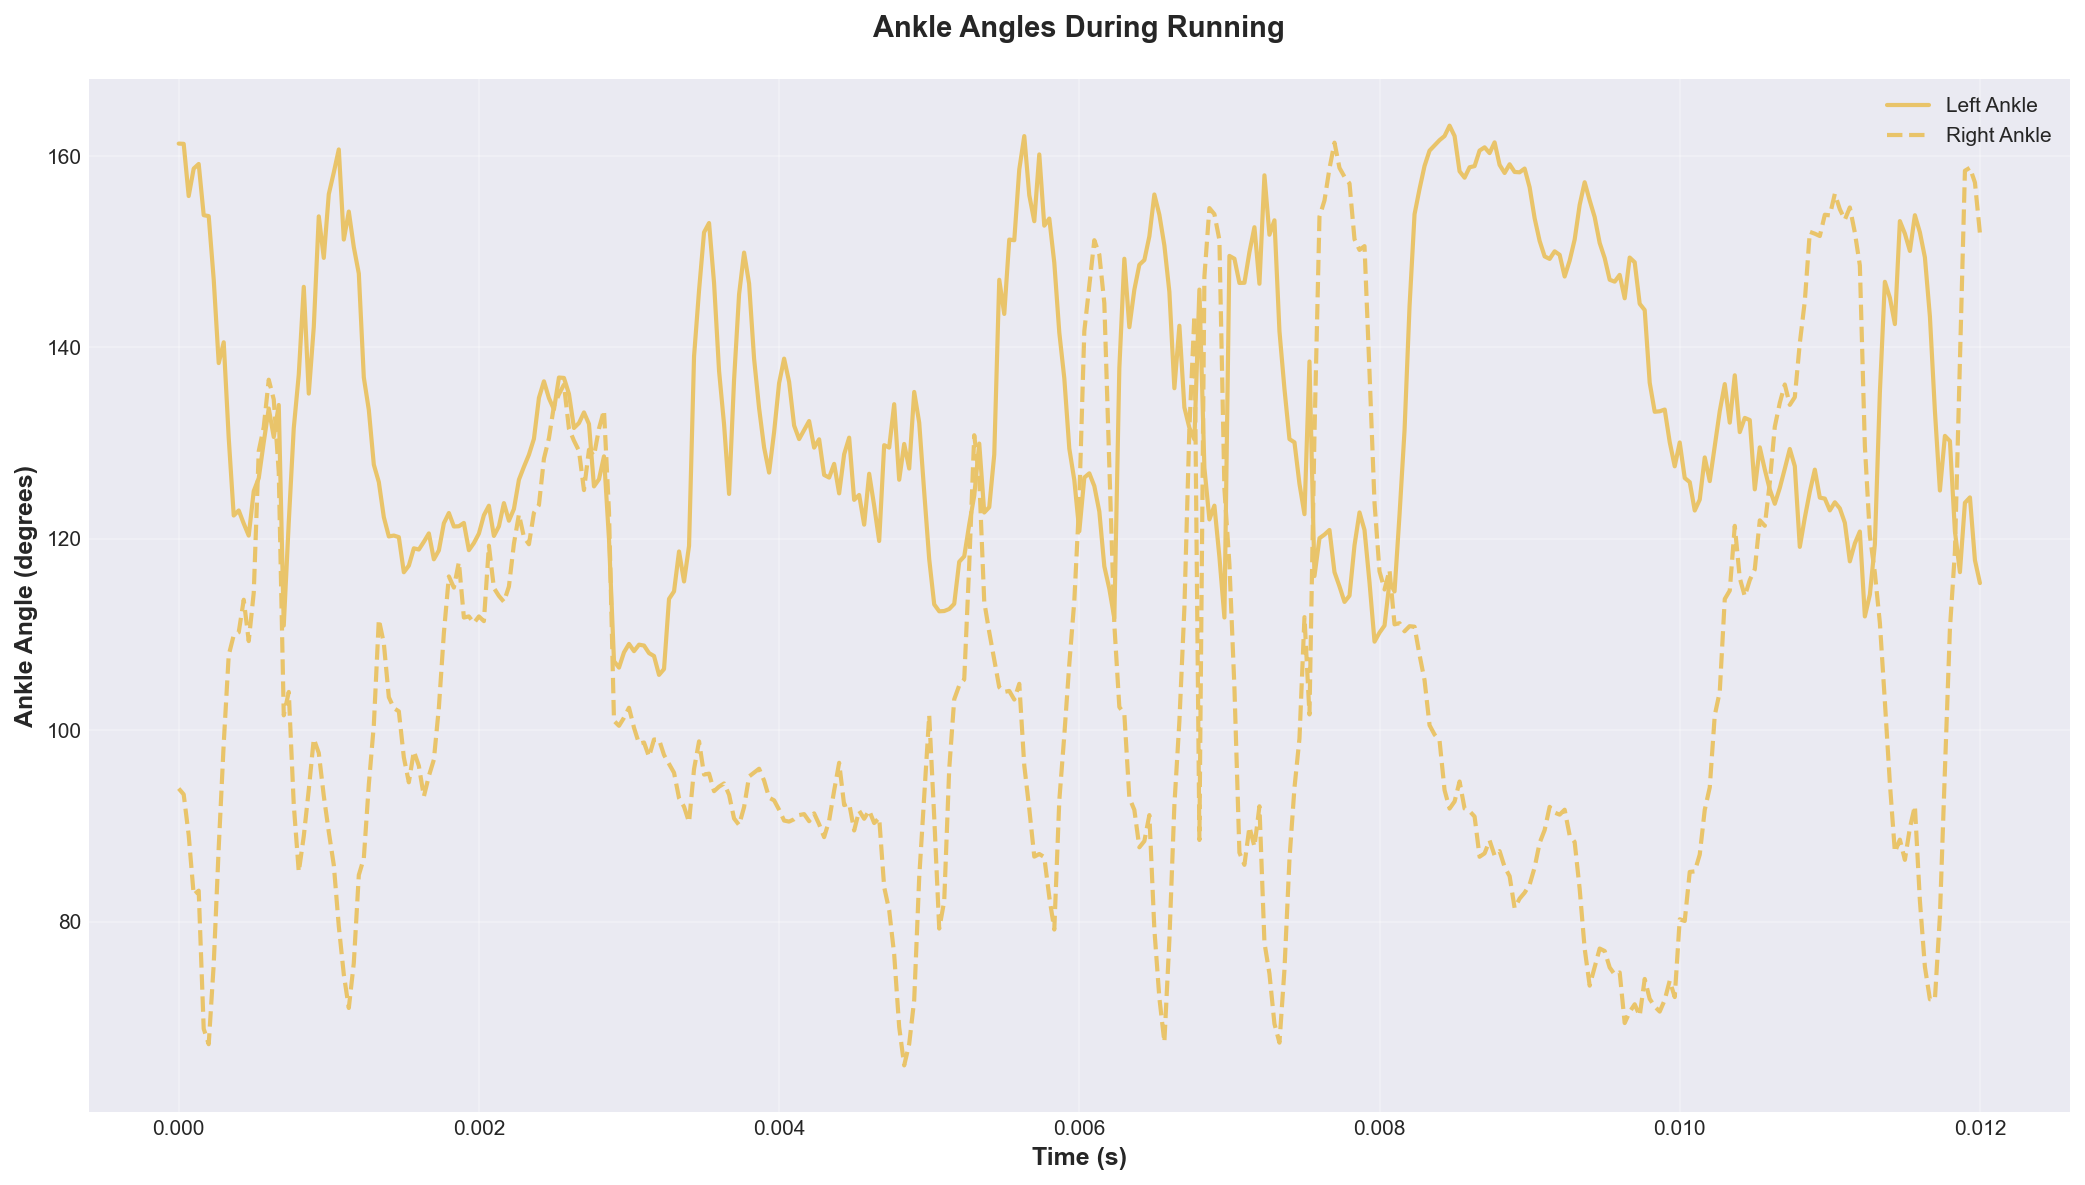

✓ Angle plots created and saved!


In [8]:
# Plot joint angles over time
plotter = MetricsPlotter(figsize=(14, 8))

# Plot knee angles
fig = plotter.plot_angles_over_time(
    angles_df,
    angles=['left_knee', 'right_knee'],
    time_column='time',
    title='Knee Angles During Running',
    xlabel='Time (s)',
    ylabel='Knee Angle (degrees)'
)
plt.savefig(output_dir / "knee_angles.png", dpi=150, bbox_inches='tight')
plt.show()

# Plot hip angles
fig = plotter.plot_angles_over_time(
    angles_df,
    angles=['left_hip', 'right_hip'],
    time_column='time',
    title='Hip Angles During Running',
    xlabel='Time (s)',
    ylabel='Hip Angle (degrees)'
)
plt.savefig(output_dir / "hip_angles.png", dpi=150, bbox_inches='tight')
plt.show()

# Plot ankle angles
fig = plotter.plot_angles_over_time(
    angles_df,
    angles=['left_ankle', 'right_ankle'],
    time_column='time',
    title='Ankle Angles During Running',
    xlabel='Time (s)',
    ylabel='Ankle Angle (degrees)'
)
plt.savefig(output_dir / "ankle_angles.png", dpi=150, bbox_inches='tight')
plt.show()

print("✓ Angle plots created and saved!")

## 8. Analyze Left-Right Symmetry

Compare left and right side joint angles to assess running symmetry.

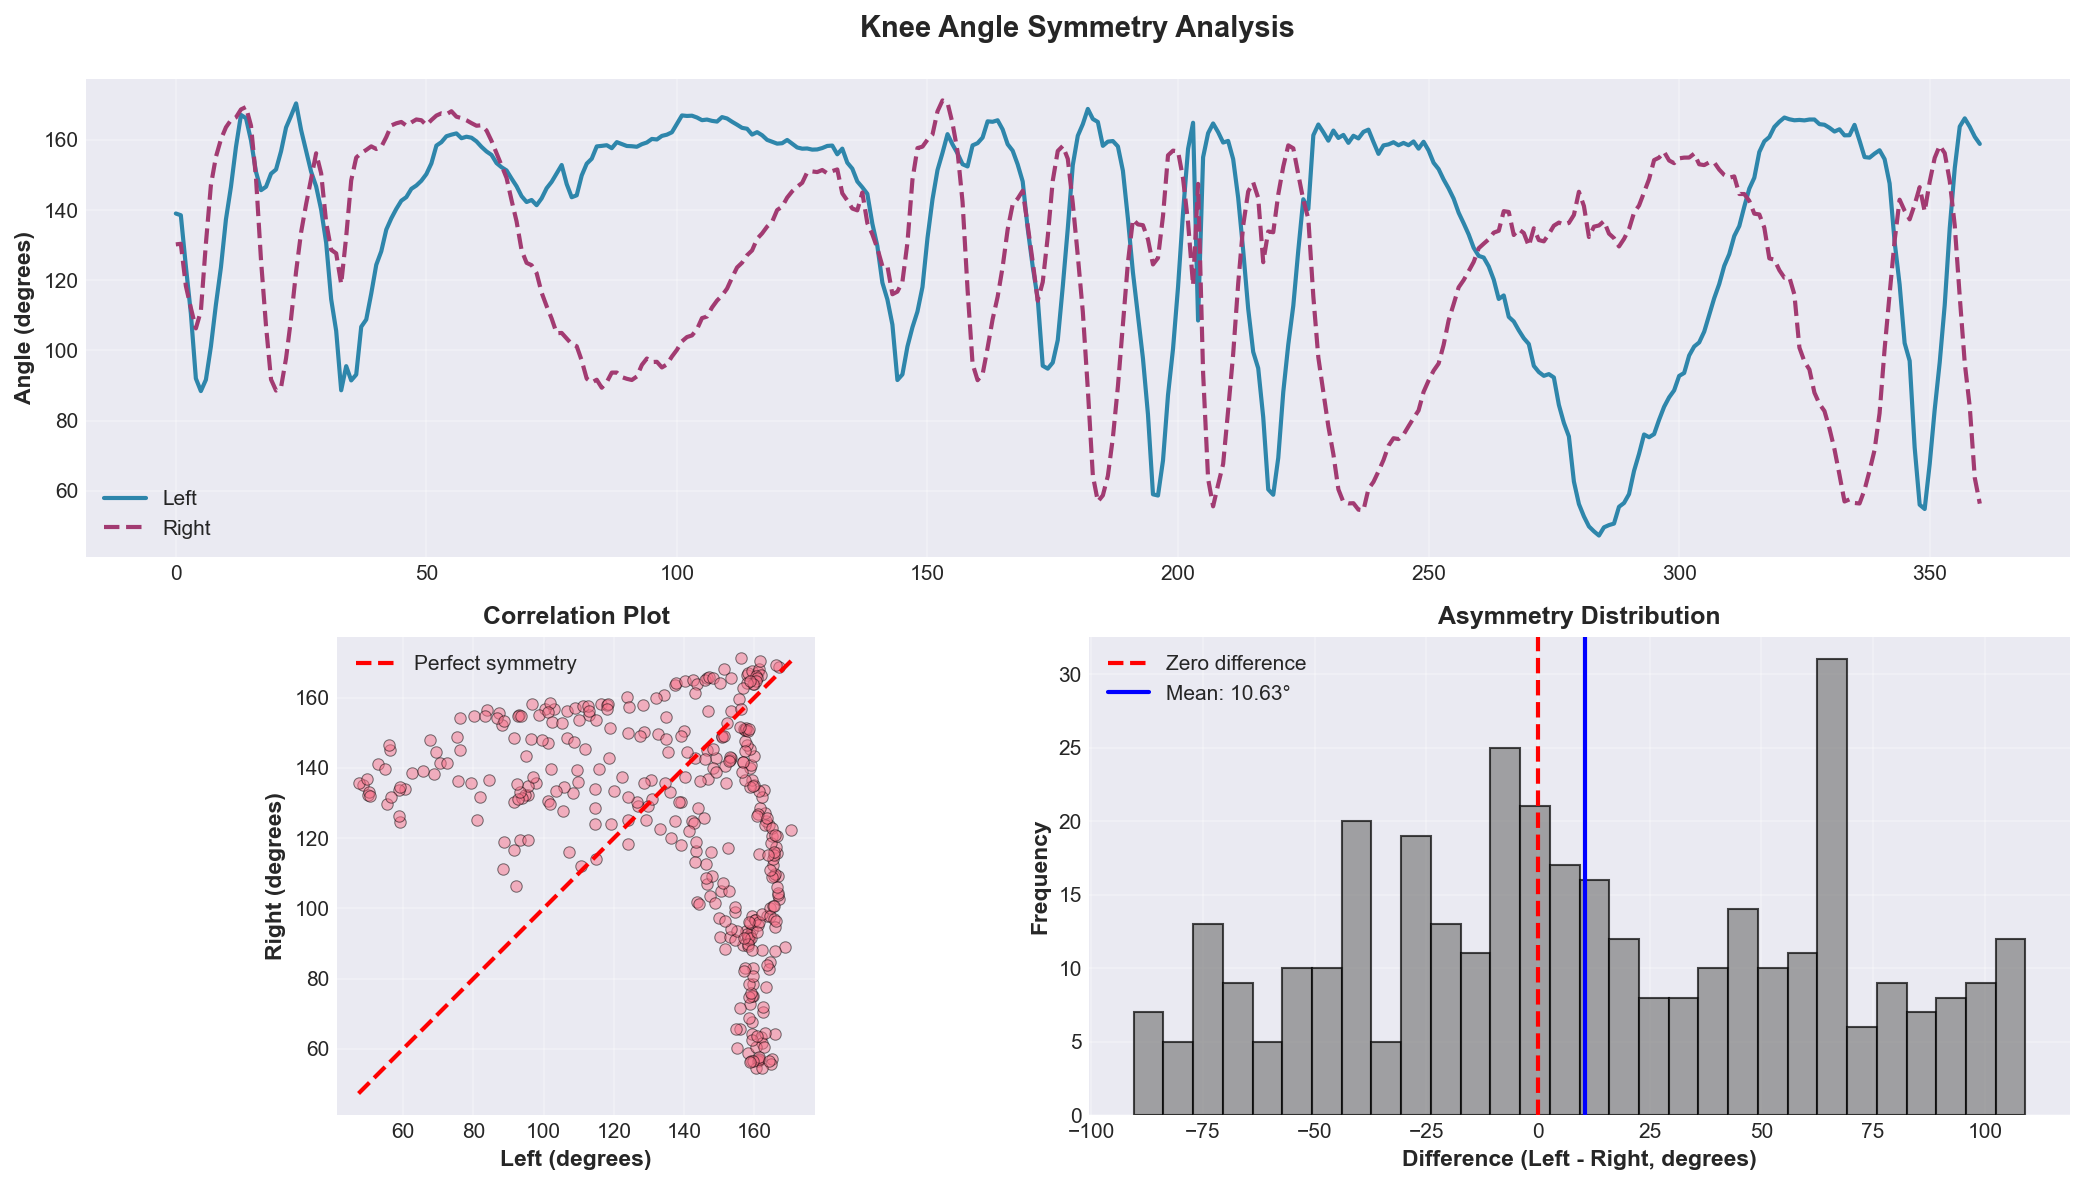

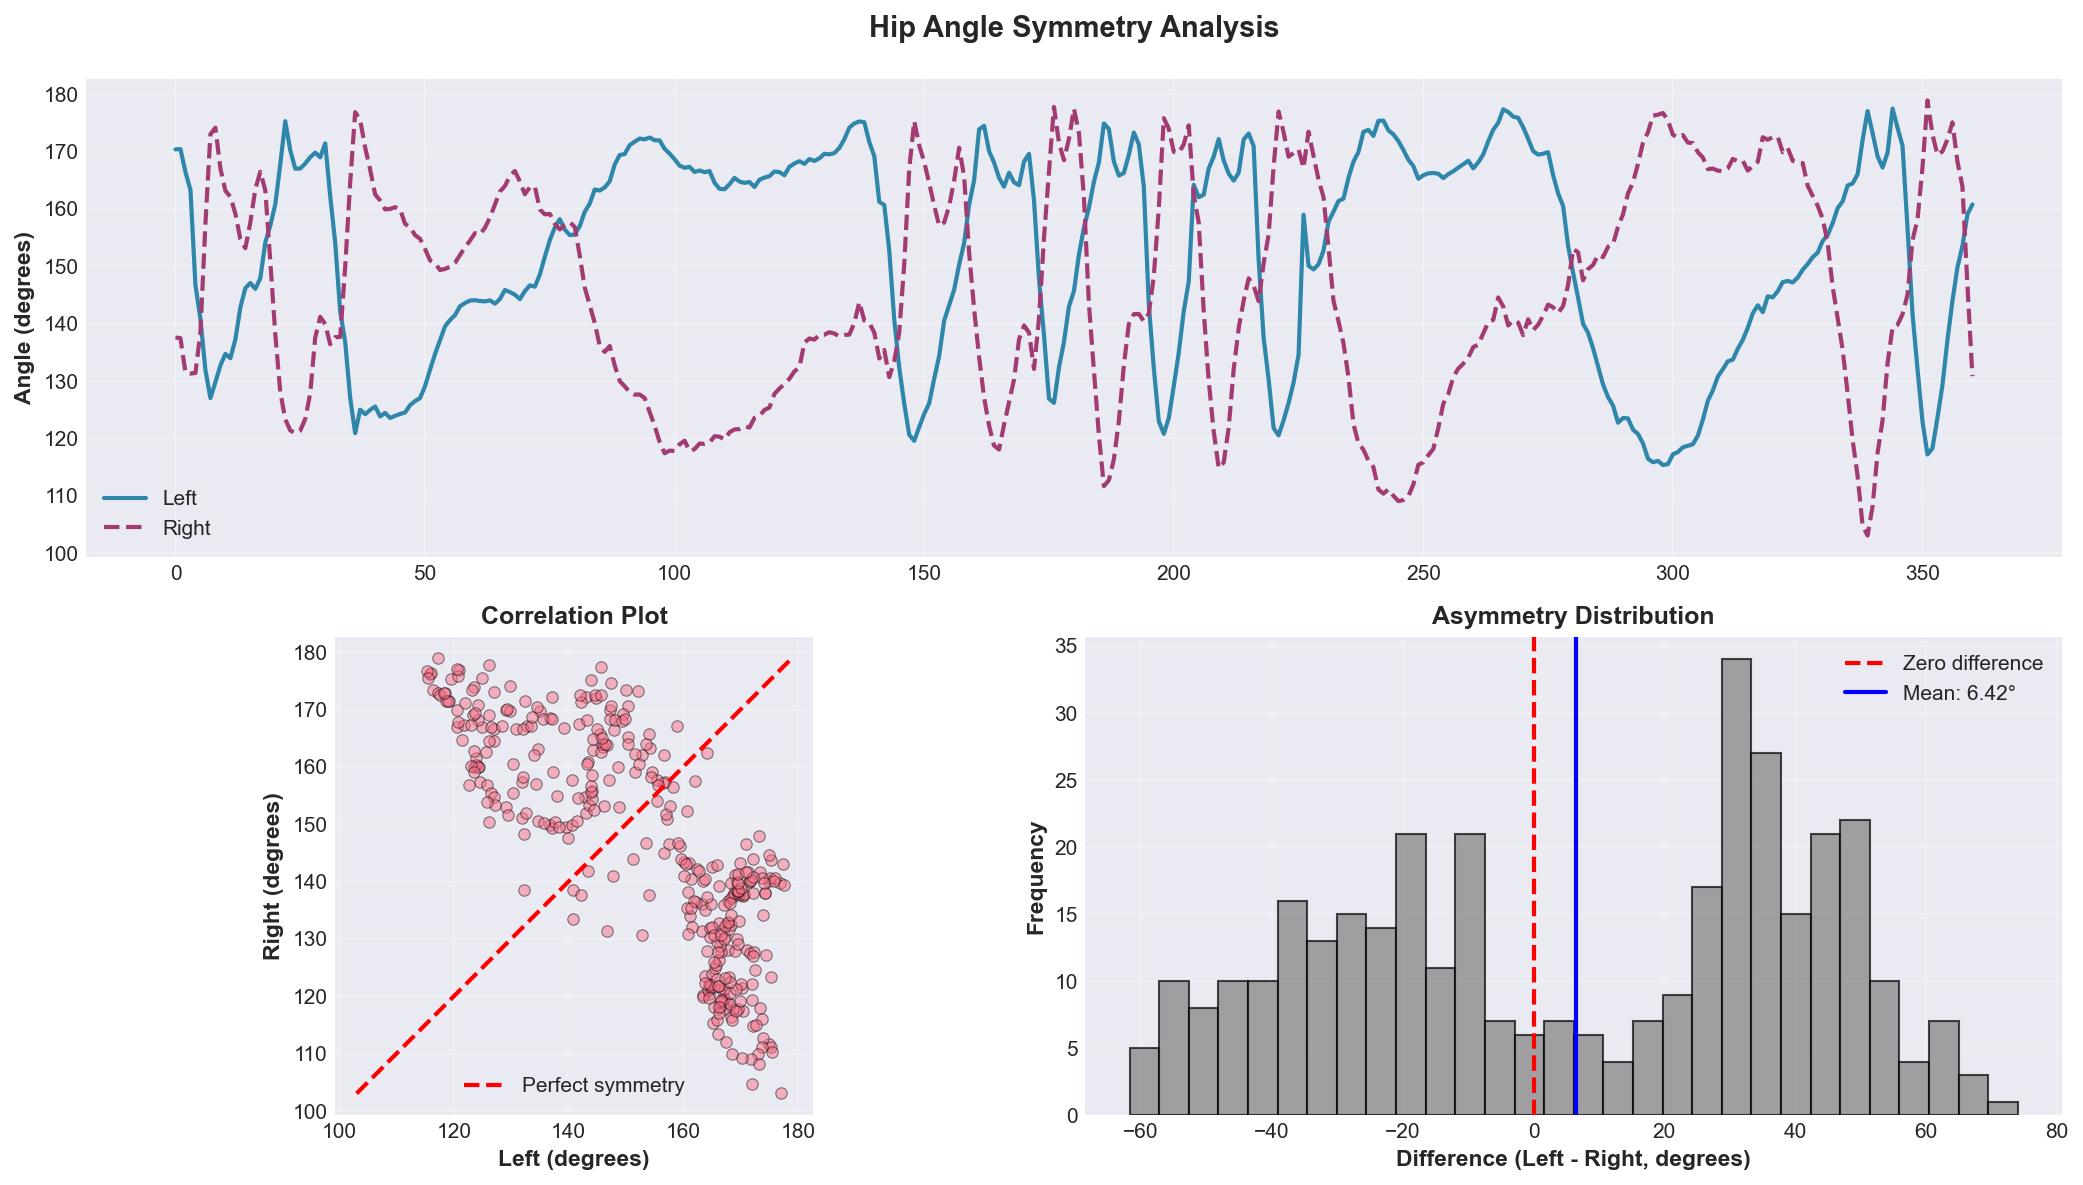


Symmetry Correlations:
  Knee angles: -0.391
  Hip angles:  -0.799

Mean Absolute Differences:
  Knee angles: 44.07°
  Hip angles:  32.24°

✓ Symmetry analysis complete!


In [9]:
# Plot knee symmetry
fig = plotter.plot_symmetry(
    angles_df,
    left_column='left_knee',
    right_column='right_knee',
    title='Knee Angle Symmetry Analysis'
)
plt.savefig(output_dir / "knee_symmetry.png", dpi=150, bbox_inches='tight')
plt.show()

# Plot hip symmetry
fig = plotter.plot_symmetry(
    angles_df,
    left_column='left_hip',
    right_column='right_hip',
    title='Hip Angle Symmetry Analysis'
)
plt.savefig(output_dir / "hip_symmetry.png", dpi=150, bbox_inches='tight')
plt.show()

# Calculate symmetry metrics
knee_correlation = angles_df[['left_knee', 'right_knee']].corr().iloc[0, 1]
hip_correlation = angles_df[['left_hip', 'right_hip']].corr().iloc[0, 1]

print(f"\nSymmetry Correlations:")
print(f"  Knee angles: {knee_correlation:.3f}")
print(f"  Hip angles:  {hip_correlation:.3f}")

# Calculate mean absolute differences
knee_diff_mean = np.abs(angles_df['left_knee'] - angles_df['right_knee']).mean()
hip_diff_mean = np.abs(angles_df['left_hip'] - angles_df['right_hip']).mean()

print(f"\nMean Absolute Differences:")
print(f"  Knee angles: {knee_diff_mean:.2f}°")
print(f"  Hip angles:  {hip_diff_mean:.2f}°")

print("\n✓ Symmetry analysis complete!")

## 9. Create Summary Dashboard

Generate a comprehensive visualization dashboard with all key metrics.

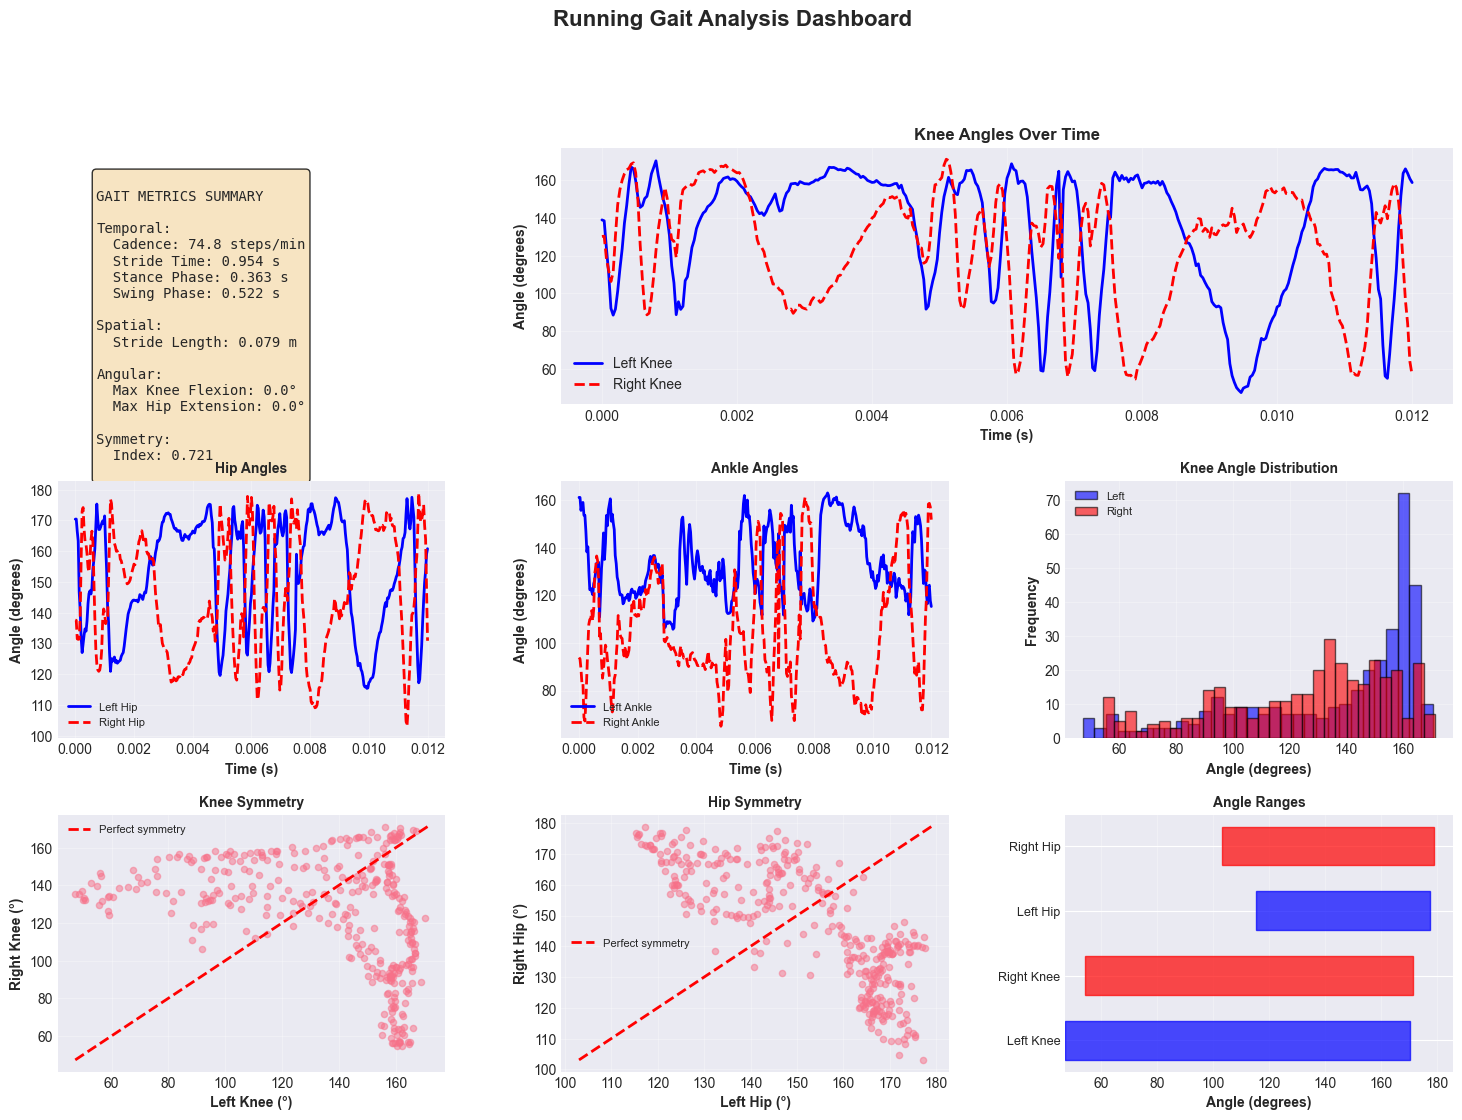

✓ Dashboard created and saved!


In [10]:
# Create comprehensive dashboard
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Gait Metrics Summary (top left)
ax1 = fig.add_subplot(gs[0, 0])
ax1.axis('off')
metrics_text = f"""
GAIT METRICS SUMMARY

Temporal:
  Cadence: {metrics.cadence:.1f} steps/min
  Stride Time: {metrics.stride_time:.3f} s
  Stance Phase: {metrics.stance_phase_duration:.3f} s
  Swing Phase: {metrics.swing_phase_duration:.3f} s

Spatial:
  Stride Length: {metrics.stride_length:.3f} m

Angular:
  Max Knee Flexion: {metrics.knee_flexion_max:.1f}°
  Max Hip Extension: {metrics.hip_extension_max:.1f}°

Symmetry:
  Index: {metrics.symmetry_index:.3f}
"""
ax1.text(0.1, 0.9, metrics_text, transform=ax1.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 2. Knee angles over time (top middle and right)
ax2 = fig.add_subplot(gs[0, 1:])
ax2.plot(angles_df['time'], angles_df['left_knee'], 'b-', linewidth=2, label='Left Knee')
ax2.plot(angles_df['time'], angles_df['right_knee'], 'r--', linewidth=2, label='Right Knee')
ax2.set_xlabel('Time (s)', fontweight='bold')
ax2.set_ylabel('Angle (degrees)', fontweight='bold')
ax2.set_title('Knee Angles Over Time', fontweight='bold', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Hip angles over time (middle left)
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(angles_df['time'], angles_df['left_hip'], 'b-', linewidth=2, label='Left Hip')
ax3.plot(angles_df['time'], angles_df['right_hip'], 'r--', linewidth=2, label='Right Hip')
ax3.set_xlabel('Time (s)', fontweight='bold')
ax3.set_ylabel('Angle (degrees)', fontweight='bold')
ax3.set_title('Hip Angles', fontweight='bold', fontsize=10)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# 4. Ankle angles over time (middle middle)
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(angles_df['time'], angles_df['left_ankle'], 'b-', linewidth=2, label='Left Ankle')
ax4.plot(angles_df['time'], angles_df['right_ankle'], 'r--', linewidth=2, label='Right Ankle')
ax4.set_xlabel('Time (s)', fontweight='bold')
ax4.set_ylabel('Angle (degrees)', fontweight='bold')
ax4.set_title('Ankle Angles', fontweight='bold', fontsize=10)
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# 5. Knee angle distribution (middle right)
ax5 = fig.add_subplot(gs[1, 2])
ax5.hist(angles_df['left_knee'].dropna(), bins=30, alpha=0.6, color='blue', label='Left', edgecolor='black')
ax5.hist(angles_df['right_knee'].dropna(), bins=30, alpha=0.6, color='red', label='Right', edgecolor='black')
ax5.set_xlabel('Angle (degrees)', fontweight='bold')
ax5.set_ylabel('Frequency', fontweight='bold')
ax5.set_title('Knee Angle Distribution', fontweight='bold', fontsize=10)
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

# 6. Symmetry scatter - Knee (bottom left)
ax6 = fig.add_subplot(gs[2, 0])
ax6.scatter(angles_df['left_knee'], angles_df['right_knee'], alpha=0.5, s=20)
min_val = min(angles_df['left_knee'].min(), angles_df['right_knee'].min())
max_val = max(angles_df['left_knee'].max(), angles_df['right_knee'].max())
ax6.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect symmetry')
ax6.set_xlabel('Left Knee (°)', fontweight='bold')
ax6.set_ylabel('Right Knee (°)', fontweight='bold')
ax6.set_title('Knee Symmetry', fontweight='bold', fontsize=10)
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)

# 7. Symmetry scatter - Hip (bottom middle)
ax7 = fig.add_subplot(gs[2, 1])
ax7.scatter(angles_df['left_hip'], angles_df['right_hip'], alpha=0.5, s=20)
min_val = min(angles_df['left_hip'].min(), angles_df['right_hip'].min())
max_val = max(angles_df['left_hip'].max(), angles_df['right_hip'].max())
ax7.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect symmetry')
ax7.set_xlabel('Left Hip (°)', fontweight='bold')
ax7.set_ylabel('Right Hip (°)', fontweight='bold')
ax7.set_title('Hip Symmetry', fontweight='bold', fontsize=10)
ax7.legend(fontsize=8)
ax7.grid(True, alpha=0.3)

# 8. Angle ranges comparison (bottom right)
ax8 = fig.add_subplot(gs[2, 2])
angle_ranges = {
    'Left Knee': [angles_df['left_knee'].min(), angles_df['left_knee'].max()],
    'Right Knee': [angles_df['right_knee'].min(), angles_df['right_knee'].max()],
    'Left Hip': [angles_df['left_hip'].min(), angles_df['left_hip'].max()],
    'Right Hip': [angles_df['right_hip'].min(), angles_df['right_hip'].max()],
}
positions = list(range(len(angle_ranges)))
labels = list(angle_ranges.keys())
ranges = [angle_ranges[label][1] - angle_ranges[label][0] for label in labels]
mins = [angle_ranges[label][0] for label in labels]

bars = ax8.barh(positions, ranges, left=mins, height=0.6, alpha=0.7)
bars[0].set_color('blue')
bars[1].set_color('red')
bars[2].set_color('blue')
bars[3].set_color('red')

ax8.set_yticks(positions)
ax8.set_yticklabels(labels, fontsize=9)
ax8.set_xlabel('Angle (degrees)', fontweight='bold')
ax8.set_title('Angle Ranges', fontweight='bold', fontsize=10)
ax8.grid(True, alpha=0.3, axis='x')

fig.suptitle('Running Gait Analysis Dashboard', fontsize=16, fontweight='bold', y=0.995)
plt.savefig(output_dir / "gait_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()

print("✓ Dashboard created and saved!")

## 10. Export Results

Save the analysis results and data for future reference.

In [11]:
# Export metrics to CSV (output_dir created in setup cell)
metrics_export = {
    'metric': ['cadence', 'stride_time', 'stride_length', 'stance_phase_duration',
               'swing_phase_duration', 'knee_flexion_max', 'hip_extension_max',
               'symmetry_index', 'analysis_duration', 'total_strides'],
    'value': [metrics.cadence, metrics.stride_time, metrics.stride_length,
              metrics.stance_phase_duration, metrics.swing_phase_duration,
              metrics.knee_flexion_max, metrics.hip_extension_max,
              metrics.symmetry_index, metrics.analysis_duration, metrics.total_strides],
    'unit': ['steps/min', 's', 'm', 's', 's', 'degrees', 'degrees', 'index', 's', 'count']
}
metrics_export_df = pd.DataFrame(metrics_export)
metrics_export_df.to_csv(output_dir / "gait_metrics.csv", index=False)
print(f"✓ Metrics exported to: {output_dir / 'gait_metrics.csv'}")

# Export angles data
angles_df.to_csv(output_dir / "joint_angles.csv", index=False)
print(f"✓ Joint angles exported to: {output_dir / 'joint_angles.csv'}")

# Export summary report
report_file = output_dir / "gait_analysis_report.txt"
with open(report_file, 'w') as f:
    f.write("="*70 + "\n")
    f.write("RUNNING GAIT ANALYSIS REPORT\n")
    f.write("="*70 + "\n\n")
    
    f.write(f"Analysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Video: {video_path.name}\n")
    f.write(f"Duration: {metrics.analysis_duration:.2f} seconds\n")
    f.write(f"Frame Rate: {fps:.2f} fps\n\n")
    
    f.write("-"*70 + "\n")
    f.write("GAIT METRICS\n")
    f.write("-"*70 + "\n\n")
    
    f.write("Temporal Metrics:\n")
    f.write(f"  Cadence:              {metrics.cadence:.1f} steps/min\n")
    f.write(f"  Stride Time:          {metrics.stride_time:.3f} s\n")
    f.write(f"  Stance Phase:         {metrics.stance_phase_duration:.3f} s\n")
    f.write(f"  Swing Phase:          {metrics.swing_phase_duration:.3f} s\n\n")
    
    f.write("Spatial Metrics:\n")
    f.write(f"  Stride Length:        {metrics.stride_length:.3f} m\n\n")
    
    f.write("Angular Metrics:\n")
    f.write(f"  Max Knee Flexion:     {metrics.knee_flexion_max:.1f}°\n")
    f.write(f"  Max Hip Extension:    {metrics.hip_extension_max:.1f}°\n\n")
    
    f.write("Symmetry:\n")
    f.write(f"  Symmetry Index:       {metrics.symmetry_index:.3f} (0-1, 1=perfect)\n")
    f.write(f"  Knee Correlation:     {knee_correlation:.3f}\n")
    f.write(f"  Hip Correlation:      {hip_correlation:.3f}\n\n")
    
    f.write("-"*70 + "\n")
    f.write("JOINT ANGLE STATISTICS\n")
    f.write("-"*70 + "\n\n")
    
    f.write(angles_df.describe().to_string())
    f.write("\n\n")
    
    f.write("-"*70 + "\n")
    f.write("LEFT SIDE METRICS\n")
    f.write("-"*70 + "\n\n")
    for key, value in metrics.left_metrics.items():
        f.write(f"  {key}: {value}\n")
    
    f.write("\n")
    f.write("-"*70 + "\n")
    f.write("RIGHT SIDE METRICS\n")
    f.write("-"*70 + "\n\n")
    for key, value in metrics.right_metrics.items():
        f.write(f"  {key}: {value}\n")
    
    f.write("\n")
    f.write("="*70 + "\n")
    f.write("END OF REPORT\n")
    f.write("="*70 + "\n")

print(f"✓ Analysis report exported to: {report_file}")

print("\n" + "="*70)
print("EXPORT COMPLETE")
print("="*70)
print(f"\nAll results saved to: {output_dir}")
print("\nGenerated files:")
print(f"  - gait_metrics.csv")
print(f"  - joint_angles.csv")
print(f"  - gait_analysis_report.txt")
print(f"  - pose_visualization.png")
print(f"  - knee_angles.png")
print(f"  - hip_angles.png")
print(f"  - ankle_angles.png")
print(f"  - knee_symmetry.png")
print(f"  - hip_symmetry.png")
print(f"  - gait_dashboard.png")

✓ Metrics exported to: /Users/pmui/SynologyDrive/research/2026/research2026/03-pose-estimation/data/outputs/gait_metrics.csv
✓ Joint angles exported to: /Users/pmui/SynologyDrive/research/2026/research2026/03-pose-estimation/data/outputs/joint_angles.csv
✓ Analysis report exported to: /Users/pmui/SynologyDrive/research/2026/research2026/03-pose-estimation/data/outputs/gait_analysis_report.txt

EXPORT COMPLETE

All results saved to: /Users/pmui/SynologyDrive/research/2026/research2026/03-pose-estimation/data/outputs

Generated files:
  - gait_metrics.csv
  - joint_angles.csv
  - gait_analysis_report.txt
  - pose_visualization.png
  - knee_angles.png
  - hip_angles.png
  - ankle_angles.png
  - knee_symmetry.png
  - hip_symmetry.png
  - gait_dashboard.png
